# Klasifikasi Rimpang — P2_CLAHE
**Preprocessing:** Grayscale → CLAHE (Contrast Limited Adaptive Histogram Equalization)

---
**Eksperimen ini menguji apakah CLAHE dapat meningkatkan akurasi klasifikasi**
dibandingkan baseline dengan cara meningkatkan kontras lokal pada citra grayscale.

In [ ]:
# Cell 1 — Import
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from library import (
    load_images, extract_glcm_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


In [ ]:
# Cell 2 — Konfigurasi
EXP_NAME = 'P2_CLAHE'

In [ ]:
# Cell 3 — Fungsi Preprocessing
# Pipeline: BGR → Grayscale → CLAHE

def preprocess(img):
    """
    P2_CLAHE: Konversi ke grayscale lalu terapkan CLAHE.
    CLAHE meningkatkan kontras lokal sehingga tekstur rimpang
    lebih terlihat jelas untuk ekstraksi fitur GLCM.
    """
    gray = manual_bgr_to_grayscale(img)
    clahe = manual_clahe(gray)
    return clahe

Total gambar loaded: 630


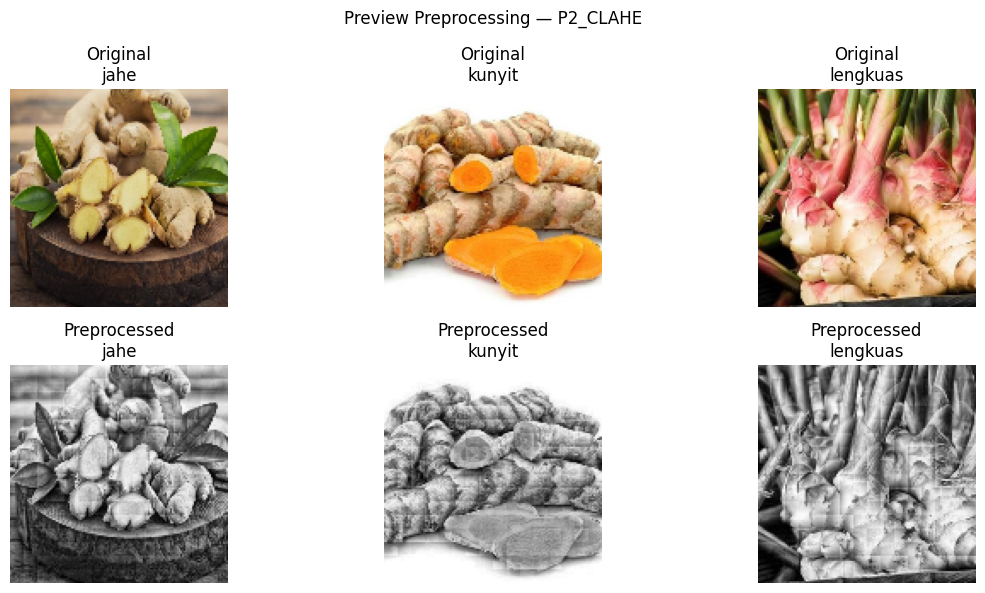

In [ ]:
# Cell 4 — Load & Preview
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

In [ ]:
# Cell 5 — Ekstraksi Fitur GLCM
X = np.array([extract_glcm_features(preprocess(img.copy())) for img in images])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 24)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P2_CLAHE.csv


In [ ]:
# Cell 5b — Split & Normalisasi
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit HANYA dari train
X_test  = scaler.transform(X_test)       # apply ke test (no fit)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 504 | Test: 126


P2_CLAHE | KNN → 53.97%
              precision    recall  f1-score   support

        jahe       0.71      0.69      0.70        42
      kunyit       0.42      0.52      0.46        42
    lengkuas       0.53      0.40      0.46        42

    accuracy                           0.54       126
   macro avg       0.55      0.54      0.54       126
weighted avg       0.55      0.54      0.54       126



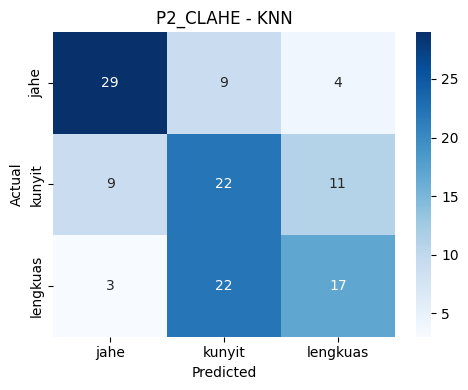

P2_CLAHE | SVM → 59.52%
              precision    recall  f1-score   support

        jahe       0.88      0.67      0.76        42
      kunyit       0.54      0.45      0.49        42
    lengkuas       0.47      0.67      0.55        42

    accuracy                           0.60       126
   macro avg       0.63      0.60      0.60       126
weighted avg       0.63      0.60      0.60       126



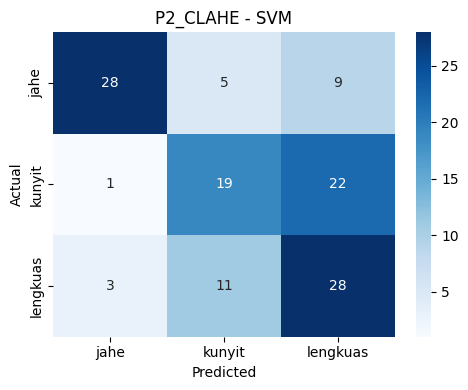

P2_CLAHE | RF → 57.14%
              precision    recall  f1-score   support

        jahe       0.74      0.69      0.72        42
      kunyit       0.52      0.55      0.53        42
    lengkuas       0.47      0.48      0.47        42

    accuracy                           0.57       126
   macro avg       0.58      0.57      0.57       126
weighted avg       0.58      0.57      0.57       126



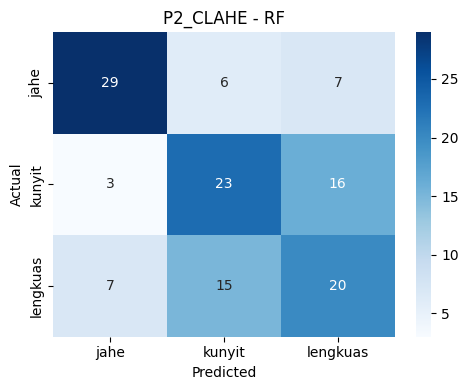


Hasil disimpan ke output/hasil_P2_CLAHE.csv
  Eksperimen Model  Akurasi
0   P2_CLAHE   KNN    53.97
1   P2_CLAHE   SVM    59.52
2   P2_CLAHE    RF    57.14


In [ ]:
# Cell 6 — Training & Evaluasi
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)